<a href="https://colab.research.google.com/github/abhichiku18/netflix-content-analysis/blob/main/netflix_content_strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud

sns.set_style('darkgrid')

In [2]:
df = pd.read_csv("netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [4]:
df.shape

(7787, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [6]:
df.describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


#Data Cleaning and Transformation

In [7]:
df.isnull()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,True,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
7782,False,False,False,False,False,False,False,False,False,False,False,False
7783,False,False,False,False,False,False,False,False,False,False,False,False
7784,False,False,False,True,False,True,False,False,False,False,False,False
7785,False,False,False,True,False,False,False,False,False,False,False,False


In [8]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...


In [9]:
df.isnull().sum( )

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


In [10]:
df['director'].fillna('Unknown')
df['cast'].fillna('Unknown')

,cast
0,"João Miguel, Bianca Comparato, Michel Gomes, R..."
1,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ..."
2,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ..."
3,"Elijah Wood, John C. Reilly, Jennifer Connelly..."
4,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar..."
...,...
7782,"Imad Creidi, Antoinette Turk, Elias Gergi, Car..."
7783,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan..."
7784,Nasty C
7785,"Adriano Zumbo, Rachel Khoo"


In [11]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


In [12]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


In [13]:
#Convert Date and Time
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [14]:
df['date_added'] = df['date_added'].ffill().bfill()

In [15]:
df.dropna(subset=['rating'],inplace=True)

In [16]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2386
cast,718
country,506
date_added,0
release_year,0
rating,0
duration,0


In [17]:
df['date_added']

,date_added
0,2020-08-14
1,2016-12-23
2,2018-12-20
3,2017-11-16
4,2020-01-01
...,...
7782,2020-10-19
7783,2019-03-02
7784,2020-09-25
7785,2020-10-31


In [18]:
df['year_added']= df['date_added'].dt.year

In [19]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020


In [20]:
df['month_added']=df['date_added'].dt.month

In [21]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1


# Exploratory Data Analysis

**Q1. What is the distribution of Movies vs TV Shows in the Netflix dataset?**

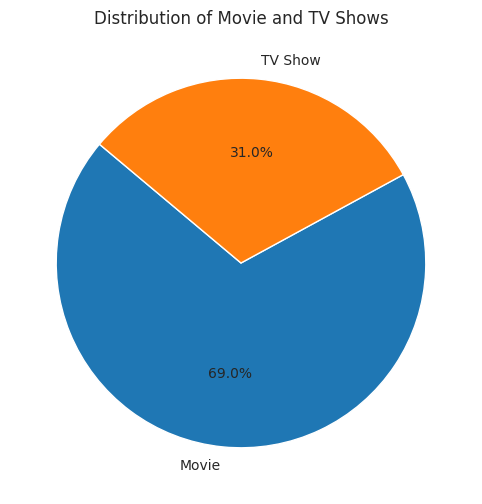

In [22]:
#Distribution
plt.figure(figsize=(8,6))
type_counts = df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Movie and TV Shows')
plt.show()

Insight:- Netflix library is dominated by Movies, which make up roughly 70% of the content in this dataset


**Q2. How has content been added over time ?**

In [23]:
content_added_over_time = df.groupby(['year_added','type']).size().unstack().fillna(0)
content_added_over_time

type,Movie,TV Show
year_added,,
2008,1.0,1.0
2009,2.0,0.0
2010,1.0,0.0
2011,13.0,0.0
2012,3.0,1.0
2013,6.0,4.0
2014,19.0,5.0
2015,58.0,21.0
2016,256.0,181.0


<Figure size 1400x800 with 0 Axes>

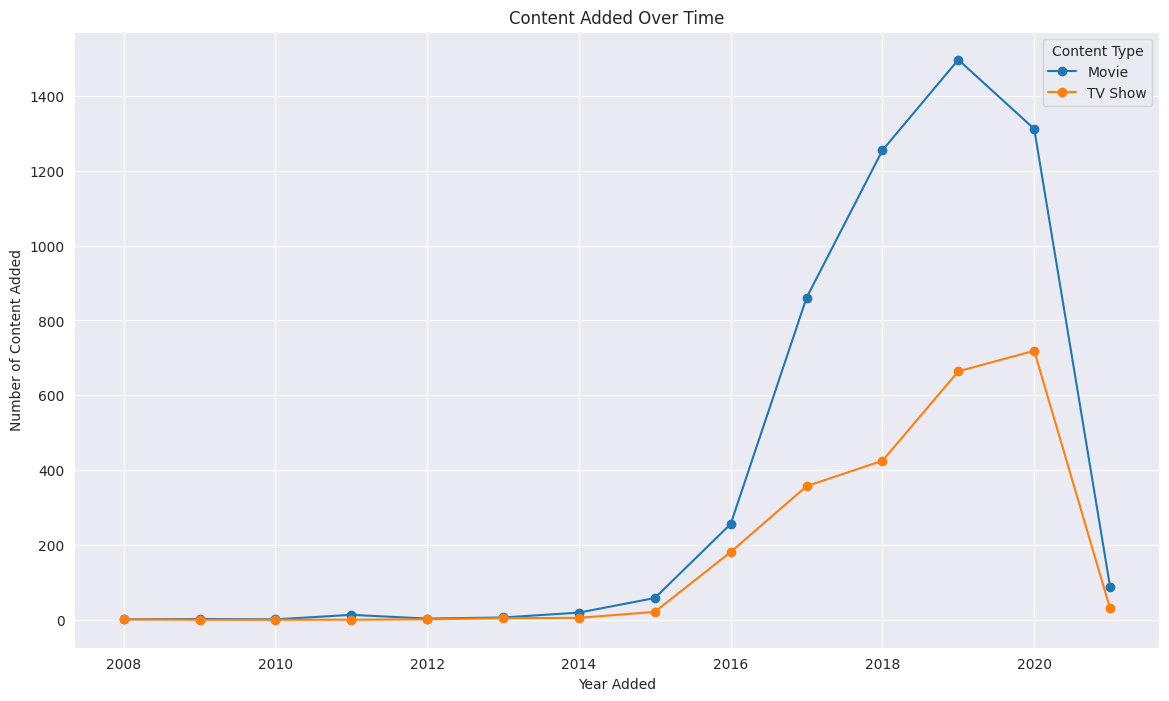

In [24]:
content_added_over_time = df.groupby(['year_added','type']).size().unstack().fillna(0)

plt.figure(figsize=(14,8))
content_added_over_time.plot(kind='line',marker='o',figsize=(14,8))
plt.title('Content Added Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Content Added')
plt.legend(title='Content Type')
plt.grid(True)
plt.show()

Insight: Netflix added very little content before 2015, but the number of titles increased rapidly after 2016, showing strong growth of the platform. Movies were consistently added in higher numbers than TV shows, indicating that movies dominate Netflix’s content library. The highest number of additions occurred around 2019, while TV shows showed steady growth from 2016 to 2020. A sharp decline appears in 2021, likely due to incomplete data or reduced releases.

**Q3. What are the most popular genres ?**

In [25]:
genres= df.assign(genres=df['listed_in'].str.split(',')).explode('genres')
genres

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,genres
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,International TV Shows
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,TV Dramas
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,TV Sci-Fi & Fantasy
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,Dramas
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,International Movies
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7784,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,2020-09-25,2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast...",2020,9,Music & Musicals
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,2020,10,International TV Shows
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,2020,10,Reality TV
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States",2020-03-01,2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...,2020,3,Documentaries


In [26]:
top_genres = genres['genres'].value_counts().reset_index().head(15)
top_genres

,genres,count
0,International Movies,2323
1,Dramas,1383
2,Comedies,1074
3,Documentaries,751
4,Dramas,722
5,Action & Adventure,721
6,International TV Shows,690
7,Independent Movies,653
8,TV Dramas,642
9,Romantic Movies,528


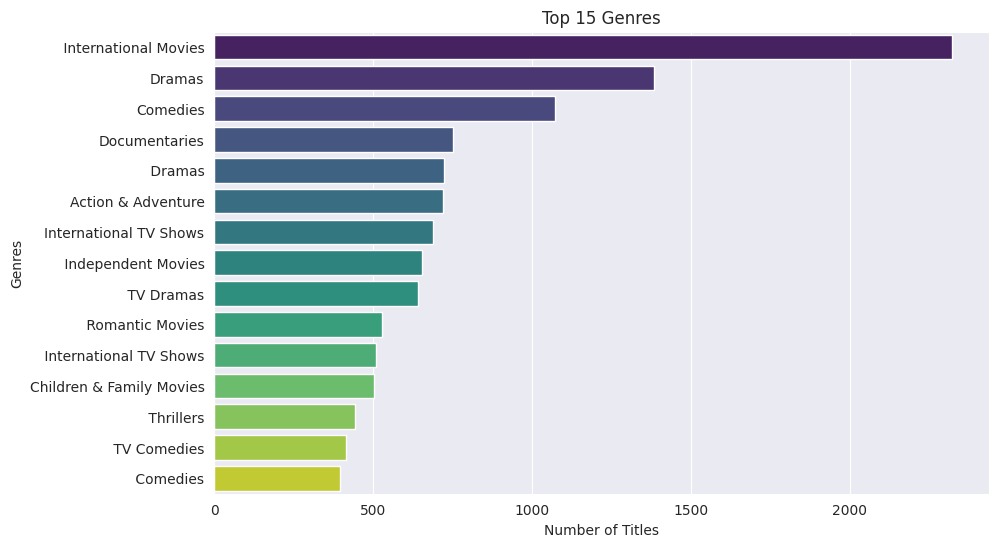

In [27]:
plt.figure(figsize=(10,6))
sns.barplot(y='genres',x='count',data=top_genres,hue='genres',palette='viridis',legend=False)
plt.title('Top 15 Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genres')
plt.show()

Insight:- The chart shows that International Movies have the highest number of titles on Netflix, making them the most dominant genre. Dramas and Comedies are also very common, indicating strong demand for storytelling and entertainment content. Other genres like Documentaries, Action & Adventure, and International TV Shows also contribute significantly, showing that Netflix offers a diverse mix of content for different audiences.

**Q4. What are distribution of Content Distribution ?**

In [28]:
movies_df = df[df['type'] == 'Movie'].copy()
tv_shows_df = df[df['type'] == 'TV Show'].copy()

In [29]:
#Clean and convert duration of movies and TV Show
movies_df['duration_min'] = movies_df['duration'].astype(str).str.replace(' min', '', regex=False).astype(int)
tv_shows_df['Season'] = tv_shows_df['duration'].astype(str).str.replace(' Seasons', '').str.replace(' Season', '').astype(int)

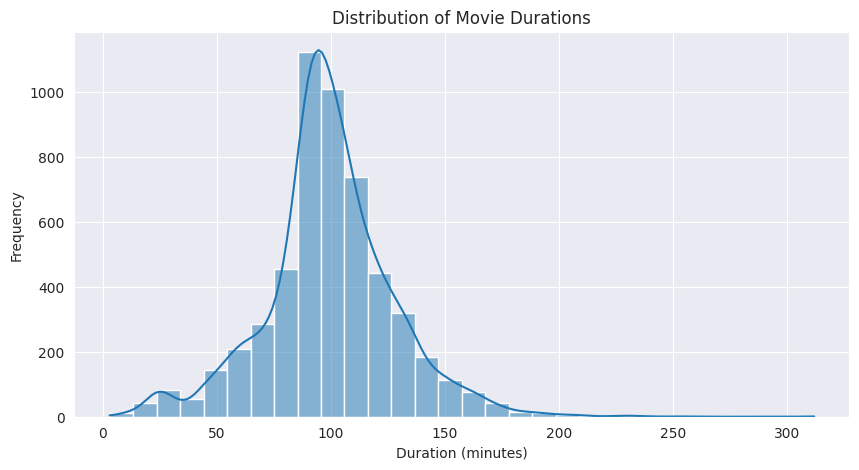

In [31]:
#Plot for distribution for Movie.
plt.figure(figsize=(10,5))
sns.histplot(movies_df['duration_min'], bins=30, kde=True)
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()


Insight:The distribution of movie durations shows that most movies on Netflix fall within the 90 to 120 minutes range, with the peak around 100 minutes, indicating that typical movie length on the platform is close to standard feature film duration. Very short movies and extremely long movies are relatively rare.

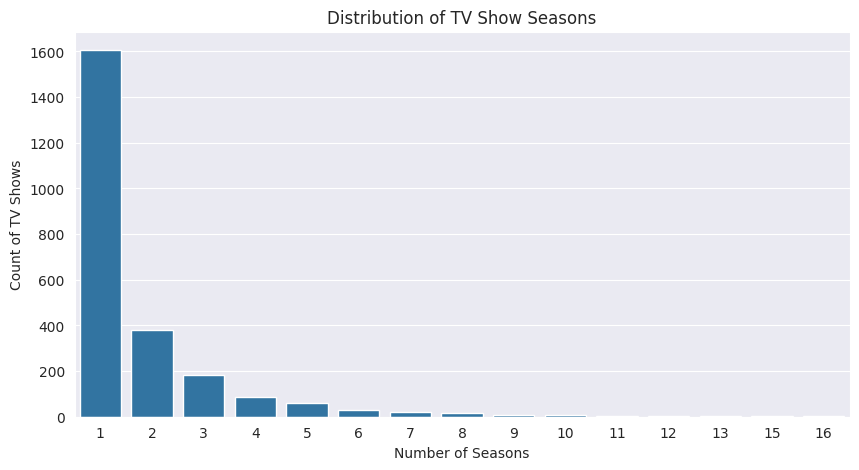

In [33]:
#Plot duration for TV Show
plt.figure(figsize=(10,5))
sns.countplot(x='Season', data=tv_shows_df)
plt.title('Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Count of TV Shows')
plt.show()

Insight:For TV shows, the distribution of seasons shows that the majority of shows have only 1 season, and the number of shows decreases as the number of seasons increases. Shows with more than 5 seasons are quite rare, indicating that most TV shows on Netflix are limited series or short-running shows.

**Q5. Where does the content come from ?**

In [34]:
df['country']

,country
0,Brazil
1,Mexico
2,Singapore
3,United States
4,United States
...,...
7782,"Sweden, Czech Republic, United Kingdom, Denmar..."
7783,India
7784,NaN
7785,Australia


In [36]:
from numpy._core.defchararray import count
countries = df.assign(country=df['country'].str.split(', ')).explode('country')
countries

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7784,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,2020-09-25,2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast...",2020,9
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,2020,10
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,United Kingdom,2020-03-01,2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...,2020,3
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,Canada,2020-03-01,2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...,2020,3


In [37]:
top_15_countries = countries['country'].value_counts().reset_index().head(15)
top_15_countries

,country,count
0,United States,3293
1,India,990
2,United Kingdom,722
3,Canada,412
4,France,349
5,Japan,286
6,Spain,215
7,South Korea,212
8,Germany,199
9,Mexico,154


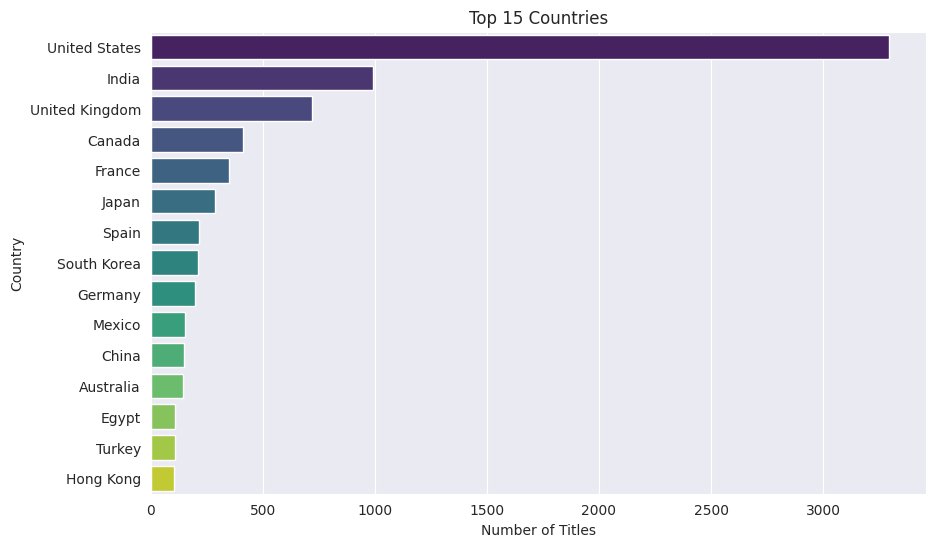

In [39]:
plt.figure(figsize=(10,6))
sns.barplot(y='country',x='count',data=top_15_countries,hue='country',palette='viridis',legend=False)
plt.title('Top 15 Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

Insight:The United States contributes the most content on Netflix with 3293 titles, followed by India (990) and the United Kingdom (722). Other countries like Canada, France, and Japan also contribute a moderate amount of content. Overall, Netflix content is dominated by the United States, with other countries contributing significantly smaller portions.


**Q6. What are the maturity ratings of the content ?**

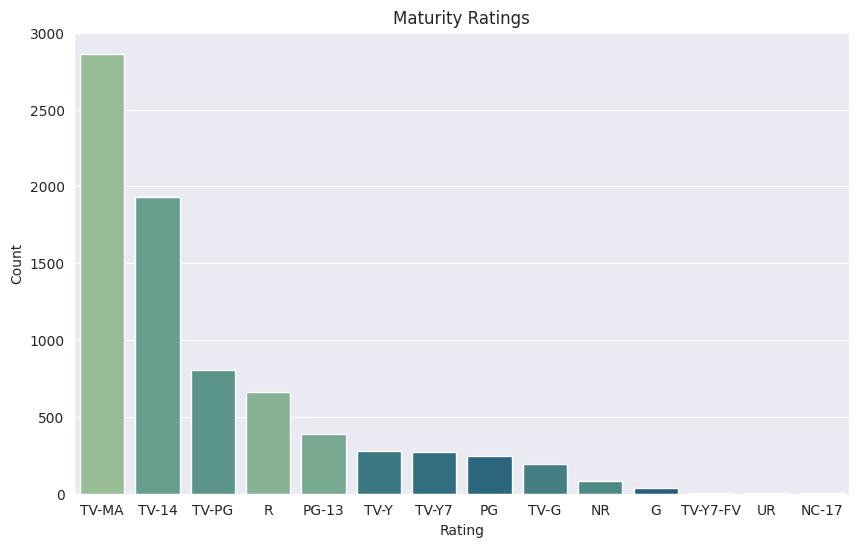

In [42]:
plt.figure(figsize=(10,6))
sns.countplot(x='rating',data=df,palette='crest',hue='rating',order=df['rating'].value_counts().index)
plt.title('Maturity Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

Insight: The chart shows that TV-MA has the highest number of titles on Netflix, followed by TV-14. This indicates that most content on the platform is targeted toward mature and teenage audiences. Ratings for younger viewers appear much less frequently, showing that Netflix mainly focuses on adult-oriented content.


# CONTENT FRESHNESS

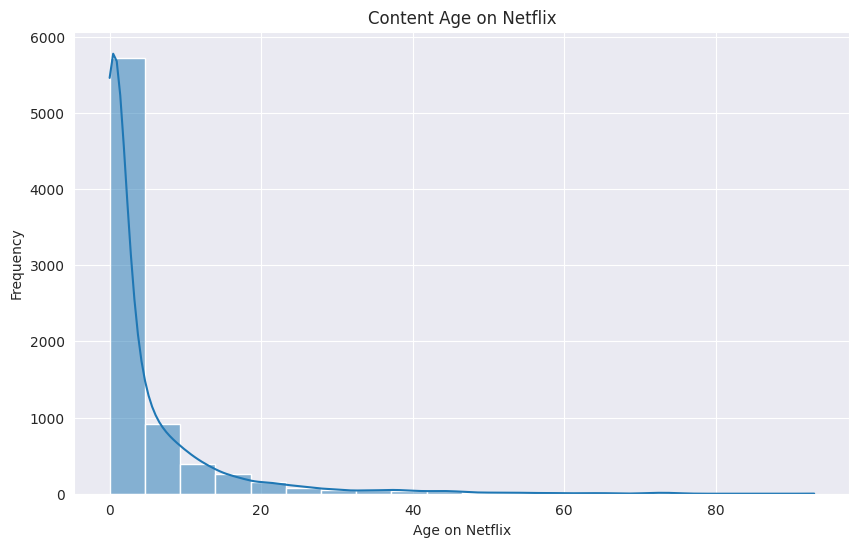

In [45]:
df['age_on_netflix'] = df['year_added']-df['release_year']
content_age = df[df['age_on_netflix'] >=0]

plt.figure(figsize=(10,6))
sns.histplot(content_age['age_on_netflix'],bins=20,kde=True)
plt.title('Content Age on Netflix')
plt.xlabel('Age on Netflix')
plt.ylabel('Frequency')
plt.show()

Insight: Netflix is focusing on originals .

# Deeper Multivariate Analysis

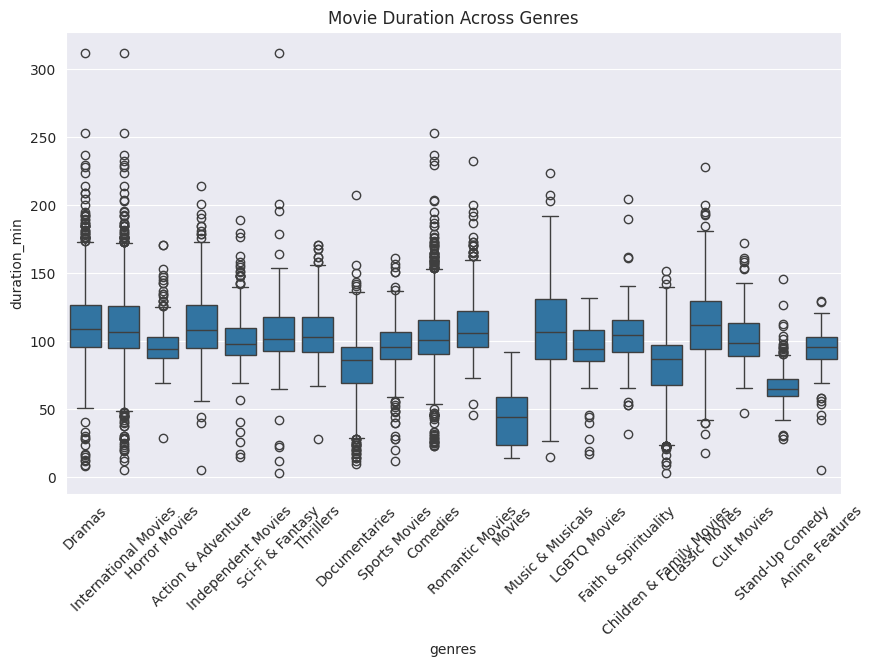

In [47]:
#Analyze movie duration across different to genres
movies_df_genres = movies_df.assign(genres=movies_df['listed_in'].str.split(', ')).explode('genres')

plt.figure(figsize=(10,6))
sns.boxplot(x='genres', y='duration_min', data=movies_df_genres)
plt.xticks(rotation=45)
plt.title('Movie Duration Across Genres')
plt.show()

Insight: Most movie genres have a typical duration of around 90–110 minutes. Genres like drama, action and adventure, and comedy tend to have slightly longer movies, while children and family movies and stand-up comedy are generally shorter. Some genres also show outliers with very short or very long durations.


# Word Cloud from Content Descriptions

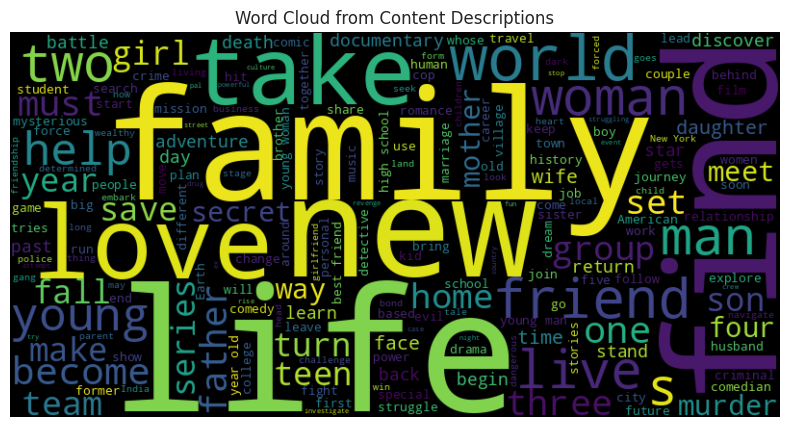

In [51]:
text = ''.join(df['description'])

wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from Content Descriptions')
plt.show()

# Content Summary
1. Movies are more numerous than TV shows in the Netflix dataset.
2. The number of titles added increased rapidly after 2016 and peaked around 2019.
3. Most movies have a duration between 90 and 120 minutes.
4. Most TV shows have only one season, indicating many short series.
5. The United States contributes the most content, followed by India and the United Kingdom.
6. The most common genres on Netflix include International Movies, Dramas, and Comedies.
7. Most content is rated TV-MA or TV-14, showing that the platform mainly targets mature and teenage audiences.
8. Overall, Netflix focuses on international content, drama-driven stories, and mature audience programming.
